# 读取数据

In [1]:
import  pandas as pd
REE_COLS = ['Ce', 'Dy', 'Er', 'Eu', 'Gd', 'Ho', 'Lu', 'Nd', 'Sm', 'Th', 'Tm', 'U', 'Yb']
# 1. 读取数据
file_path = r'G:\PythonProject\Bishe\data\raw\BiShe-total_data.CSV'
df = pd.read_csv(file_path)
df

,lat,lon,class,Ce,Dy,Er,Eu,Gd,Ho,Lu,Nd,Sm,Th,Tm,U,Yb
0,40.49,-121.51,magmatic,8.45,31.79,58.36,0.49,5.73,12.14,28.29,0.30,0.85,32.0,14.37,65.0,139.69
1,40.49,-121.51,magmatic,46.28,66.46,189.80,0.51,14.86,37.68,88.34,0.57,1.69,314.0,46.54,511.0,436.00
2,40.49,-121.51,magmatic,68.14,90.61,225.64,0.85,21.73,45.38,96.36,0.72,2.46,757.0,53.23,811.0,501.76
3,40.49,-121.51,magmatic,170.38,303.39,519.85,2.95,70.00,111.31,217.11,2.78,7.38,3497.0,119.34,2127.0,1104.03
4,40.49,-121.51,magmatic,18.54,41.55,87.39,0.27,7.40,16.25,42.14,0.14,0.81,67.0,21.60,137.0,199.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7213,-25.17,-50.08,hydrothermal,1046.00,183.00,117.00,9.00,147.00,35.00,24.00,1046.00,242.00,6098.0,20.00,2046.0,162.00
7214,-25.17,-50.08,hydrothermal,1461.00,341.00,230.00,15.00,252.00,69.00,41.00,1257.00,339.00,7620.0,39.00,2035.0,298.00
7215,-25.17,-50.08,hydrothermal,1267.00,284.00,183.00,9.00,214.00,56.00,29.00,1274.00,291.00,3615.0,30.00,1386.0,217.00
7216,-25.17,-50.08,hydrothermal,1196.00,298.00,209.00,10.00,205.00,64.00,36.00,1384.00,343.00,3559.0,35.00,950.0,267.00


In [2]:
# 移除缺失标签的样本
df_labeled = df.dropna(subset=['class']).copy()
# 处理特征缺失值 - 使用中位数填充
for col in REE_COLS:
    df_labeled[col] = df_labeled[col].fillna(df_labeled[col].median())

# PCA降维

In [3]:
from sklearn.decomposition import PCA
X = df_labeled.drop(['lat','lon','class'], axis=1)  # 特征
y = df_labeled['class'] # 标签
# n_components=None：保留所有主成分
pca = PCA(n_components=None)
pca_result = pca.fit_transform(X)  # 拟合+转换数据

# 将PCA结果转为DataFrame，方便后续使用
pca_df = pd.DataFrame(
    pca_result,
    columns=[f'PC{i+1}' for i in range(pca_result.shape[1])]
)
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-812.440876,-12.968259,-225.136914,-0.130318,-13.248198,-9.084660,7.830531,8.735868,-4.527531,-2.926767,1.384891,0.878844,-0.637724
1,-232.156166,60.335158,-11.175336,12.768755,-13.792177,-54.806427,8.413921,-20.707037,10.688347,13.404772,4.071604,-2.517339,0.730685
2,226.611911,347.036765,-22.558293,12.970353,-21.824511,-64.730006,11.197342,-32.690970,5.834127,13.756510,3.091463,-3.269945,0.391231
3,2629.237107,2324.687176,240.360570,52.912115,-107.590164,-116.103218,45.413688,-92.131867,-22.359451,1.366566,7.087442,-7.409562,-4.368569
4,-719.509763,-10.962286,-174.823030,3.480265,-10.408865,-16.107544,5.143742,0.971531,-1.691663,-0.530172,1.581386,0.661872,-2.178416
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6885,3372.128714,4854.340716,-889.176852,25.708348,870.901210,-410.430634,-430.004039,335.765333,322.124824,-69.659771,-2.446782,-25.939271,-1.579385
6886,4010.164601,6282.657670,-763.030673,15.701925,1198.046096,-471.920585,-623.418953,342.454039,313.159738,-53.545484,-3.184339,-18.092295,-3.276022
6887,1840.737448,2864.107564,-491.694524,-30.690133,1291.497104,-328.679650,-680.980089,419.668639,394.052783,-81.642754,-10.701022,-45.595175,-4.265400
6888,1441.298260,2983.881072,-340.447267,-32.869693,1289.538556,-306.675270,-663.207399,519.619926,483.347490,-89.161468,1.005343,-15.724005,1.866477


In [5]:
y

0           magmatic
1           magmatic
2           magmatic
3           magmatic
4           magmatic
            ...     
7213    hydrothermal
7214    hydrothermal
7215    hydrothermal
7216    hydrothermal
7217    hydrothermal
Name: class, Length: 6890, dtype: object

# 划分数据集

In [6]:
from sklearn.model_selection import train_test_split

# 将数据集按7:3划分为训练数据、验证数据、测试数据
x_train, x_test, y_train, y_test = train_test_split(pca_df, y, test_size=0.3, random_state=42,stratify=y)
x_valid,x_test,y_valid,y_test = train_test_split(x_test,
                                                   y_test,
                                                   test_size=0.5,
                                                   random_state=42,
                                                   stratify=y_test)

In [7]:
# 标签编码
from sklearn.preprocessing import LabelEncoder

# 1. 初始化编码器
le = LabelEncoder()

# 2. 只用训练集拟合
y_train_encoded = pd.DataFrame(le.fit_transform(y_train),index=None,columns=['label'])
y_valid_encoded = pd.DataFrame(le.transform(y_valid),index=None,columns=['label'])

# 3. 测试集只做transform（不能再fit）
y_test_encoded = pd.DataFrame(le.transform(y_test),index=None,columns=['label'])

# 查看类别对应关系
print("类别映射关系：")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name} -> {i}")

类别映射关系：
detrital -> 0
hydrothermal -> 1
magmatic -> 2
metamorphic -> 3


# 数据集保存

In [8]:
# 保存数据集
x_train.to_csv( 'G:/PythonProject/Bishe/data/processed/x_train_PCA.csv')
x_valid.to_csv( 'G:/PythonProject/Bishe/data/processed/x_valid_PCA.csv')
x_test.to_csv( 'G:/PythonProject/Bishe/data/processed/x_test_PCA.csv')
y_train_encoded.to_csv('G:/PythonProject/Bishe/data/processed/y_train_PCA.csv')
y_valid_encoded.to_csv('G:/PythonProject/Bishe/data/processed/y_valid_PCA.csv')
y_test_encoded.to_csv('G:/PythonProject/Bishe/data/processed/y_test_PCA.csv')

In [9]:
x_train

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
4133,-611.955266,-26.261837,-52.876024,8.842779,-20.260227,-5.410601,8.826539,2.523661,3.758388,1.259651,1.123493,-0.399387,0.025282
1389,-768.981058,49.881411,-150.703353,-6.337672,-3.173654,-13.229654,-0.769425,-0.272462,-8.139024,-1.395163,-0.859954,0.369694,-0.230606
5666,-603.896735,59.441686,2.222486,-11.418159,-6.853788,39.528298,-6.486654,0.894204,-2.627654,0.425048,-3.000017,-1.416560,0.315666
6749,108.082685,-2.003680,-304.774430,-11.221567,29.649164,50.883122,-23.034368,27.270626,7.061748,5.196623,1.015404,3.140038,2.126257
1225,-751.352834,22.245134,-99.640775,-7.642294,-15.338315,-1.337950,4.863676,2.823790,-0.031120,-2.395408,-1.991809,2.252183,-0.591182
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3665,-287.510662,-64.925690,-132.597957,8.525348,-23.960163,-22.873904,14.459338,3.762190,3.395822,1.738493,1.596085,0.081788,-2.481875
5273,1532.592888,93.602265,309.160371,-34.351480,-46.255946,77.094568,-1.016750,-29.227559,19.474719,-0.277042,-7.819111,1.121627,2.648106
6310,-446.234517,4.907613,-224.220193,-6.278816,-12.503499,16.196379,1.189296,-1.295443,-1.035994,-2.968605,0.295480,0.710143,0.347987
6519,-450.209892,124.706587,30.760363,11.253338,2.936271,-13.775436,-7.968505,-17.844474,-3.560806,4.909390,3.688565,-2.102847,-2.782154


In [10]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-812.440876,-12.968259,-225.136914,-0.130318,-13.248198,-9.084660,7.830531,8.735868,-4.527531,-2.926767,1.384891,0.878844,-0.637724
1,-232.156166,60.335158,-11.175336,12.768755,-13.792177,-54.806427,8.413921,-20.707037,10.688347,13.404772,4.071604,-2.517339,0.730685
2,226.611911,347.036765,-22.558293,12.970353,-21.824511,-64.730006,11.197342,-32.690970,5.834127,13.756510,3.091463,-3.269945,0.391231
3,2629.237107,2324.687176,240.360570,52.912115,-107.590164,-116.103218,45.413688,-92.131867,-22.359451,1.366566,7.087442,-7.409562,-4.368569
4,-719.509763,-10.962286,-174.823030,3.480265,-10.408865,-16.107544,5.143742,0.971531,-1.691663,-0.530172,1.581386,0.661872,-2.178416
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6885,3372.128714,4854.340716,-889.176852,25.708348,870.901210,-410.430634,-430.004039,335.765333,322.124824,-69.659771,-2.446782,-25.939271,-1.579385
6886,4010.164601,6282.657670,-763.030673,15.701925,1198.046096,-471.920585,-623.418953,342.454039,313.159738,-53.545484,-3.184339,-18.092295,-3.276022
6887,1840.737448,2864.107564,-491.694524,-30.690133,1291.497104,-328.679650,-680.980089,419.668639,394.052783,-81.642754,-10.701022,-45.595175,-4.265400
6888,1441.298260,2983.881072,-340.447267,-32.869693,1289.538556,-306.675270,-663.207399,519.619926,483.347490,-89.161468,1.005343,-15.724005,1.866477


# 相关性热图

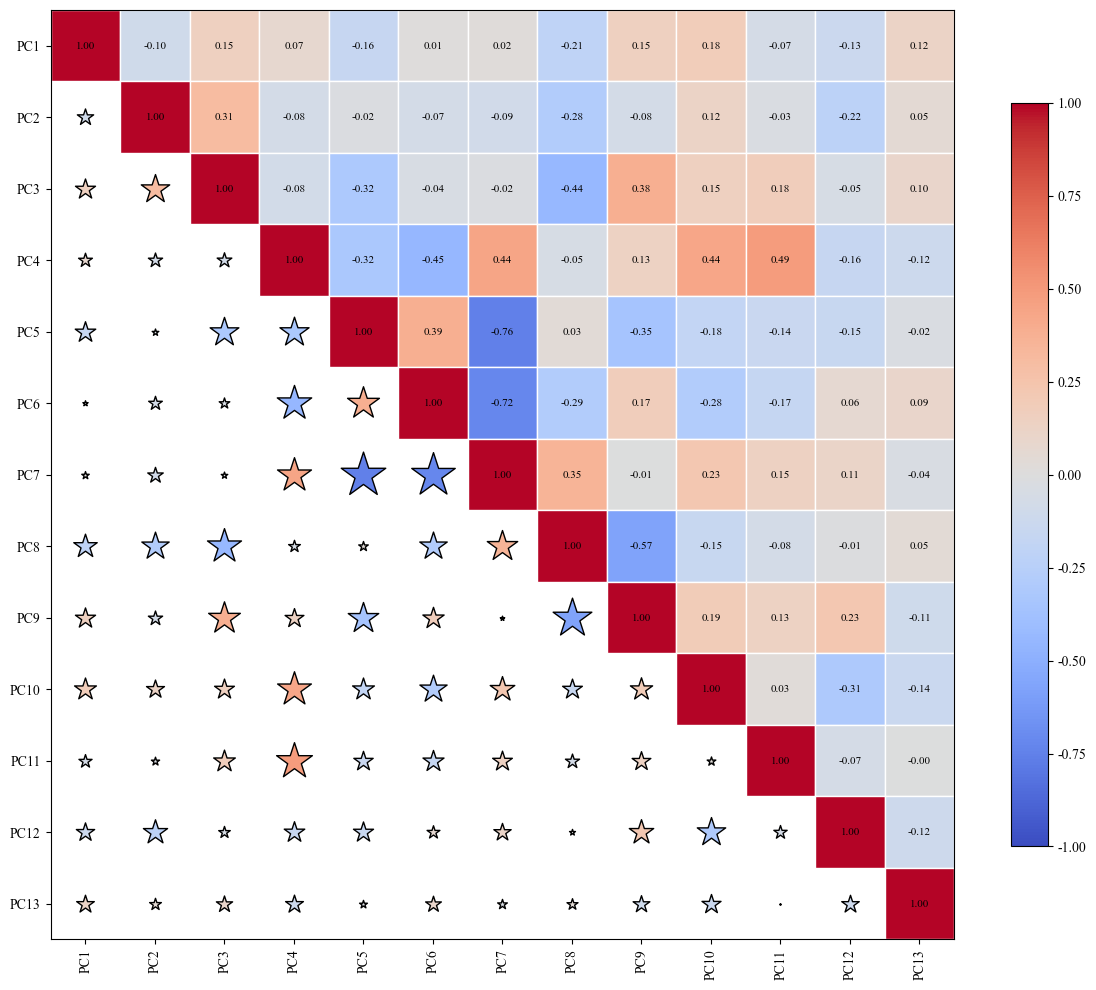

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ========== 基础设置 ==========
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['axes.unicode_minus'] = False

# 计算斯皮尔曼相关系数矩阵
matrix = pca_df.corr(method='spearman')
labels = matrix.columns
n = len(labels)

fig, ax = plt.subplots(figsize=(12,10))

# 设置坐标范围
ax.set_xlim(0, n)
ax.set_ylim(0, n)
# 关闭坐标轴网格
ax.grid(False)

# 颜色映射
cmap = plt.cm.coolwarm
norm = plt.Normalize(-1, 1)

for i in range(n):
    for j in range(n):
        value = matrix.iloc[i, j]

        # -------- 上三角（数值）--------
        if i <= j:
            ax.add_patch(plt.Rectangle((j, n-i-1), 1, 1,
                                       facecolor=cmap(norm(value)),
                                       edgecolor='white'))
            ax.text(j+0.5, n-i-1+0.5,
                    f"{value:.2f}",
                    ha='center', va='center',
                    fontsize=8)

        # -------- 下三角（五角星）--------
        else:
            size = abs(value) * 1500   # 控制星星大小

            ax.scatter(j+0.5, n-i-1+0.5,
                       s=size,
                       c=[cmap(norm(value))],
                       marker='*',
                       edgecolors='black')

# 设置坐标轴
ax.set_xticks(np.arange(n)+0.5)
ax.set_yticks(np.arange(n)+0.5)
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels[::-1])
# ax.set_title("Spearman Correlation Matrix", fontsize=14)

# 添加颜色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('Feature Correlation Matrix PCA',dpi=600,bbox_inches='tight')
plt.show()